### **Chapter 6.3: Gaussian Process Learning and GP-based MPC**

Chapter 6.2 built a learning-based MPC around a Bayesian linear regression (BLR) model of the terrain and showed that a probabilistic model enables constraint tightening. Every model learned there was, however, handed a strong hint: the trigonometric basis already encoded that the terrain is periodic with a frequency close to the true one. This chapter asks two questions that follow naturally from that observation.

- **What does the structure buy, and what does it cost when it is wrong?** We compare the structured BLR model against a **Gaussian process (GP)**, the standard black-box choice for learning robot dynamics, on data with a **gap**: a stretch of terrain the car never visited. Both models return a mean and a variance, but they place their prior in very different places, and the difference only becomes visible where there is no data. We also look at what happens when the structural assumption is misspecified, and how the assumption can be checked before its variance is trusted.

- **What does the variance actually buy in closed loop?** A learned probabilistic model predicts one step ahead. A predictive controller needs a whole trajectory, so the uncertainty has to be **propagated over the prediction horizon** and converted into constraint tightening. We embed the GP in a stochastic MPC with an **active speed limit**, trace out the trade-off between performance and constraint satisfaction as a function of the confidence level, and show that the tightening is only as good as the variance that drives it.

The plant is the mountain car of Chapter 6.2 on the same bumpy terrain, $h(p) = k\cos(18p)$ with $k = 0.01$. Data is collected everywhere except an unexplored gap in the middle of the domain, so the learned model is confident at the edges and ignorant in the middle, and the controller has to cross the gap while respecting the speed limit.

The content is summarized in the table below.

<style>
  table td:nth-child(2) {
    text-align: left;
  }
</style>

<table border="1" style="border-collapse: collapse;">  <!-- Title Row -->
  <tr>
    <th colspan="2" style="text-align:center">Chapter 6.3</th>
  </tr>

  <!-- Row group 1 -->
  <tr>
    <td rowspan="2">Gaussian Process Model Learning</td>
    <td>Example 1.1: Structured vs. Black-Box Models on Data with a Gap</td>
  </tr>
  <tr>
    <td>Example 1.2: Detecting Misspecification with the Marginal Likelihood</td>
  </tr>

  <!-- Row group 2 -->
  <tr>
    <td rowspan="2">Gaussian Process MPC</td>
    <td>Example 2.1: Certainty-Equivalent Control vs. Constraint Tightening</td>
  </tr>
  <tr>
    <td>Example 2.2: When the Uncertainty Estimate Is Miscalibrated</td>
  </tr>

</table>

<br>

First, we need to set up our Python environment and import relevant packages.

In [1]:
import sys
import os
import numpy as np
import casadi as ca
import scipy.linalg
import matplotlib.pyplot as plt
from acados_template import AcadosModel, AcadosOcp, AcadosOcpSolver

sys.path.insert(0, os.path.abspath(".."))  # prioritize this checkout over other copies
from utils.env import *
from utils.simulator import *
from ex2_LQR.lqr_utils import *
from ex5_MPC.mpc_utils import *
from ex6_SysID.SysID_utils import *

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

<br>

----

### **Experimental Setup**

The real environment is the bumpy terrain of Chapter 6.2 (`case = 3`, $k = 0.01$). Two things change with respect to that chapter.

- **The data has a gap.** Measurements of the terrain height are collected on $p \in [-2, -0.5] \cup [0.5, 2]$ and nowhere in between. The task drives the car from $p = -0.5$ to $p = 0.5$, straight through the unexplored region.

- **The speed limit is active.** In Chapter 6.2 the velocity bound was $|v| \le 4$ and the closed-loop trajectory peaked at $|v| \approx 0.77$, so no state constraint was ever active and constraint tightening had nothing to do. Here we impose $v \le v_{\max} = 0.6$, which the nominal controller would like to violate. Everything the tightening does is then visible in the trajectory.

- **Reference Arguments:**

    - Task: $\boldsymbol{x}_0 = [-0.5, 0]^\top$, $\boldsymbol{x}_T = [0.5, 0]^\top$, horizon $N = 20$, control frequency `10` Hz, `8` s of simulation.

    - Constraints: $p \in [-2, 2]$, $v \in [-0.6, 0.6]$, $a \in [-8, 8]$.

    - Costs: $\boldsymbol{Q} = \text{diag}([5,5])$, $R = 0.1$, $\boldsymbol{Q}_f = \boldsymbol{Q}$.

    - Data: `150` samples on $p \in [-2,-0.5] \cup [0.5, 2]$, zero-mean Gaussian measurement noise with standard deviation $\sigma$ as `0.005`, no data on $p \in [-0.5, 0.5]$.

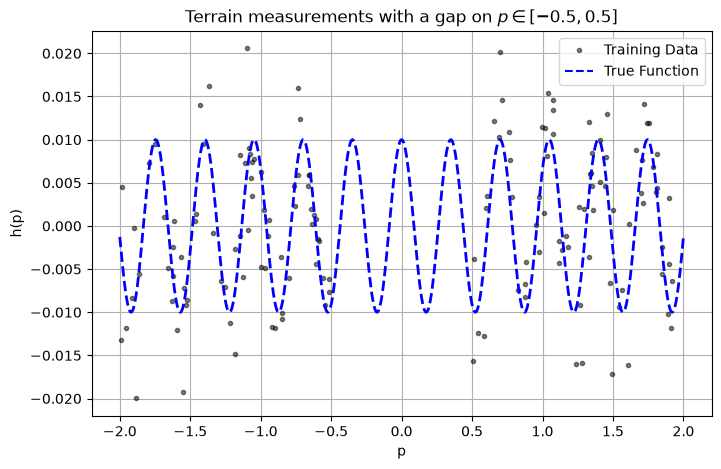

In [2]:
# Real environment
case_real = 3
terrain_param = 0.01

# Task
initial_position, initial_velocity = -0.5, 0.0
target_position, target_velocity = 0.5, 0.0
x0 = np.array([initial_position, initial_velocity])
xT = np.array([target_position, target_velocity])

# Constraints. The speed limit is the constraint of interest: the nominal controller
# would like to travel at about 0.77 m/s, so 0.6 m/s is active and must be respected.
v_max = 0.6
state_lbs = np.array([-2.0, -v_max])
state_ubs = np.array([ 2.0,  v_max])
input_lbs, input_ubs = -8.0, 8.0

# Controller
N = 20
Q = np.diag([5, 5])
R = np.array([[0.1]])
Qf = Q

# Simulation
freq = 10
t_terminal = 8

# Data collection: measurements everywhere except an unexplored gap
gap = (-0.5, 0.5)
num_samples = 150
sigma_meas = 0.005

# The true system, used only to simulate the plant
env_real = Env(case_real, x0, xT, param=terrain_param, state_lbs=state_lbs,
               state_ubs=state_ubs, input_lbs=input_lbs, input_ubs=input_ubs)
dynamics_real = Dynamics(env_real)

# Collect the dataset once; both parts of this chapter use the same data
np.random.seed(49) # for reproducibility
data_gen = GenerateData(p_range=[(-2.0, gap[0]), (gap[1], 2.0)], num_samples=num_samples,
                        case=case_real, param=terrain_param)
data_gen.set_noise(mean=0.0, std=sigma_meas) # (I.I.D.) zero-mean Gaussian noise
p_train, h_train = data_gen.generate_data()
true_func = data_gen.get_symbolic_function()

p_test = np.linspace(-2.0, 2.0, 801).reshape(-1, 1)
in_gap = (p_test.ravel() > gap[0]) & (p_test.ravel() < gap[1])

data_gen.plot(title="Terrain measurements with a gap on $p \\in [-0.5, 0.5]$")
plt.show()


<br>

----

### **Part 1: Gaussian Process Model Learning**

#### **Example 1.1: Structured vs. Black-Box Models on Data with a Gap**

Both models are Bayesian and both return a mean and a variance, but they place their prior in very different places.

**Bayesian linear regression** puts the prior on a finite set of coefficients,

$$
h(p) = \boldsymbol{\phi}(p)^\top \boldsymbol{\theta}, \qquad \boldsymbol{\theta} \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0),
$$

so the **latent-function** posterior variance at a test point, $\boldsymbol{\phi}(p)^\top \boldsymbol{\Sigma}_{\boldsymbol{\theta}} \boldsymbol{\phi}(p)$, depends on the data only through $\boldsymbol{\Sigma}_{\boldsymbol{\theta}}$. Once the data pins down the coefficients *anywhere*, the model is confident *everywhere* the basis is valid.

**Gaussian process regression** puts the prior directly on the function, without an explicitly supplied finite basis,

$$
h(p) \sim \mathcal{GP}\big(0,\; k(p, p')\big), \qquad k(p, p') = \sigma_f^2 \exp\!\left(-\frac{(p - p')^2}{2\ell^2}\right),
$$

and the posterior variance at a test point grows back towards the prior $\sigma_f^2$ as soon as that point is more than a few lengthscales $\ell$ away from any data. Its confidence is *local*. The RBF kernel still makes a structural assumption (stationary, very smooth functions). Its two hyperparameters $\ell$ (how fast the function may vary) and $\sigma_f$ (how large it may be) set its scale within that kernel family, and they have to be chosen. The principled choice is to maximize the **log marginal likelihood** of the data, which we do here by grid search.

To expose the difference between the two priors we fit four models to exactly the same data and compare them over the full range $p \in [-2, 2]$, including the gap:

- **BLR, correct basis:** $\boldsymbol{\phi}(p) = [1, \sin 18p, \cos 18p]^\top$, which contains the true terrain. Its frequency is supplied as an oracle assumption, not learned from the data.

- **BLR, incorrect basis:** $\boldsymbol{\phi}(p) = [1, \sin 12p, \cos 12p]^\top$, a periodic structure with a deliberately wrong, fixed frequency. No choice of coefficients can reproduce the terrain, so the model error is **bias**, not noise.

- **GP, tuned:** squared-exponential kernel, $\ell$ and $\sigma_f$ maximizing the log marginal likelihood on the training data.

- **GP, untuned:** the same kernel with hyperparameters chosen without looking at the data, $\ell = 0.5$ (about an eighth of the domain) and $\sigma_f = 0.01$ (of the order of the terrain height).

**Matched setup.** All four models receive the same 150 input-height pairs, known observation noise variance, zero prior mean, evaluation grid, and fresh evaluation noise. For both BLRs we use $\Sigma_0 = (s_f^2/2)I_3$: since $1+\sin^2(kp)+\cos^2(kp)=2$, their marginal prior height variance is $s_f^2$, matching the GP parameterization. Both BLRs and the tuned GP select $s_f$ from the same grid using training-data evidence. Only the GP also searches over lengthscale. The untuned GP is intentionally a fixed-hyperparameter control.

**Scope of the comparison.** This compares different structural priors, not inherently different inference accuracy: BLR is itself a GP with kernel $k_{\rm BLR}(p,p')=\phi(p)^\top\Sigma_0\phi(p')$. A GP using that same kernel and mean gives the same posterior. Frequency 18 gives the correct BLR privileged knowledge of the true terrain; no conclusion here establishes general BLR superiority. Neither method integrates hyperparameter uncertainty after selection. Metrics use the full domain; the first plots zoom to $[-1,1]$.

We judge the models on two separate questions:

- Is the **mean** right? Measured by the RMS prediction error against the true terrain.

- Is the **error bar** right? The models predict a distribution for a *new measurement*, so we test the bands against new noisy observations of the terrain, $h_{\text{obs}} = h_{\text{true}} + \varepsilon$ with the same noise level as the training data, and measure the normalized error $z = (h_{\text{obs}} - \mu) / \sigma$. A well-calibrated model has $\mathrm{RMS}(z) \approx 1$ and a 2-sigma coverage close to `95.4%`. If $\mathrm{RMS}(z) \gg 1$ the model is **overconfident**, its bounds are too tight, so nominal coverage is not supported by this check. If $\mathrm{RMS}(z) \ll 1$ the model is **over-conservative**, the bands may be wider than necessary on this evaluation set.

Height-comparison bands describe **new noisy observations**. The slope plot and MPC instead use **latent slope uncertainty**, with no added measurement noise. Calibration on one fixed terrain and one training seed is a diagnostic, not a repeated-experiment or control-safety guarantee.
A selected scale at a grid boundary should be read as a search-range limitation. In this run the incorrect-frequency BLR chooses the smallest allowed amplitude, largely shrinking its unsupported periodic signal toward zero.


In [3]:
def trig_basis(freq):
    '''Basis phi(p) = [1, sin(freq p), cos(freq p)] for a single frequency.'''
    return [lambda p: np.ones_like(p),
            lambda p, k=freq: np.sin(k * p),
            lambda p, k=freq: np.cos(k * p)]


def predictive(model, p_test):
    '''Predictive mean and standard deviation of a new measurement (model uncertainty plus noise).'''
    mean, std = model.predict(p_test, include_noise=True)
    return mean.ravel(), std.ravel()


def plot_model(model, p_test, true_func, ax, gap=None, title=None, legend=True,
               ylim=(-0.03, 0.03), xlim=(-1.0, 1.0)):
    '''Draw one model's mean and 1/2/3-sigma bands. Identical for BLR and GP, so the
    panels of the comparison can be read against each other directly.'''
    mean, std = predictive(model, p_test)
    p_flat = p_test.ravel()

    if gap is not None:
        ax.axvspan(gap[0], gap[1], color='gray', alpha=0.15, zorder=0)
    ax.plot(p_flat, [float(true_func(p)) for p in p_flat], 'b--', linewidth=2, label='True function')
    ax.plot(model.p_train, model.h_train, 'k.', alpha=0.5, markersize=6, label='Training data')
    ax.plot(p_flat, mean, color='red', linewidth=2, label='Model prediction')
    for i in range(1, 4):
        ax.fill_between(p_flat, mean - i*std, mean + i*std, color='coral',
                        alpha=0.15 if i == 3 else 0.3,
                        label='Observation predictive band (3 std.)' if i == 3 else None)
    ax.set_xlabel('p'); ax.set_ylabel('h(p)'); ax.grid(True)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if title:
        ax.set_title(title, fontsize=11)
    if legend:
        ax.legend(fontsize=8, loc='lower left')


def calibration_report(models, labels, p_test, true_func, gap, noise_std, seed=7):
    '''
    Compare the error a model actually makes against the error bar it claims.

    The RMS error is measured against the true terrain. The band is tested against new
    noisy observations h_obs = h_true + noise: with z = (h_obs - mean) / std, a
    well-calibrated predictive model has RMS(z) close to 1 and covers 95.4 % of the
    observations with +-2 std. RMS(z) > 1 means overconfident (bounds too tight, so
    constraint tightening based on them is unsafe); RMS(z) < 1 means over-conservative.
    '''
    h_true = np.array([float(true_func(p)) for p in p_test.ravel()])
    h_obs = h_true + np.random.default_rng(seed).normal(0.0, noise_std, h_true.shape)
    in_gap = (p_test.ravel() > gap[0]) & (p_test.ravel() < gap[1])

    print(f"{'model':<28}{'region':<12}{'RMS error':>11}{'mean std':>11}{'RMS z':>8}{'2-sigma cov.':>14}")
    print("-" * 84)
    for model, label in zip(models, labels):
        mean, std = predictive(model, p_test)
        for region_name, mask in (("with data", ~in_gap), ("in the gap", in_gap)):
            err = h_true[mask] - mean[mask]
            z = (h_obs[mask] - mean[mask]) / std[mask]
            print(f"{label:<28}{region_name:<12}{np.sqrt(np.mean(err**2)):>11.5f}"
                  f"{np.mean(std[mask]):>11.5f}{np.sqrt(np.mean(z**2)):>8.2f}"
                  f"{100*np.mean(np.abs(z) < 2):>13.1f}%")
    print("-" * 84)
    print(f"RMS amplitude of the true terrain inside the gap: {np.sqrt(np.mean(h_true[in_gap]**2)):.5f} "
          f"(a model predicting only zero scores exactly this); measurement noise std: {noise_std}.")
    print("Nominal 2-sigma coverage of new observations for a calibrated model: 95.4%.")

BLR prior signal std: correct basis 0.00757, incorrect basis 0.00050
GP hyperparameters from marginal likelihood: lengthscale = 0.0780, signal std = 0.00757


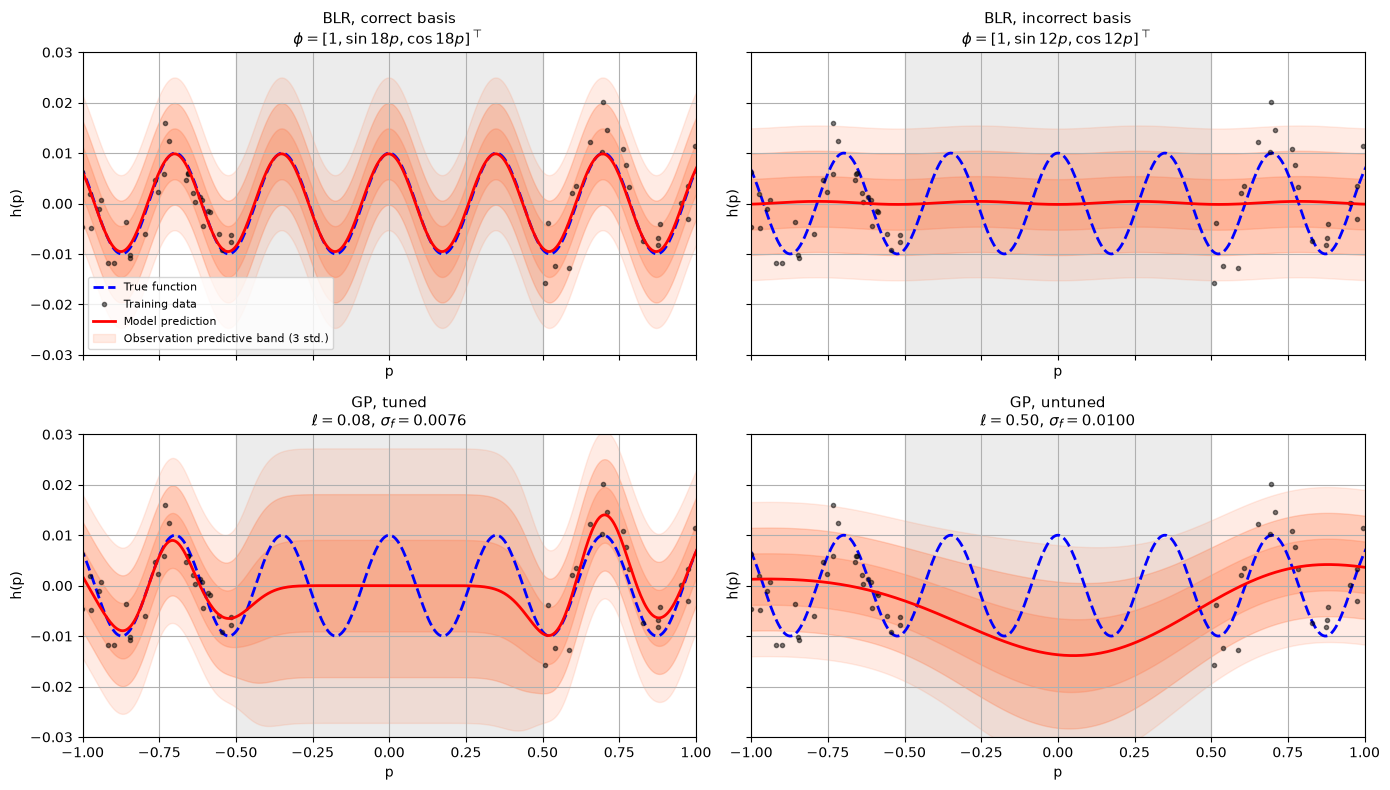

model                       region        RMS error   mean std   RMS z  2-sigma cov.
------------------------------------------------------------------------------------
BLR, correct basis          with data       0.00041    0.00505    0.95         96.3%
BLR, correct basis          in the gap      0.00039    0.00505    0.96         97.0%
BLR, incorrect basis        with data       0.00713    0.00502    1.74         71.1%
BLR, incorrect basis        in the gap      0.00693    0.00502    1.69         73.4%
GP, tuned                   with data       0.00200    0.00556    0.97         95.3%
GP, tuned                   in the gap      0.00704    0.00874    0.95         98.0%
GP, untuned                 with data       0.00723    0.00514    1.70         73.1%
GP, untuned                 in the gap      0.01262    0.00641    2.01         63.3%
------------------------------------------------------------------------------------
RMS amplitude of the true terrain inside the gap: 0.00691 (a mode

In [4]:
# Shared observation noise and signal-scale grid. Only training data selects hyperparameters.
lengthscale_grid = np.logspace(-2, np.log10(2.0), 50)
signal_std_grid = np.logspace(np.log10(5e-4), -1, 40)

def fit_blr_with_scale(frequency):
    # ||phi(p)||^2 = 2, so Sigma0 = sf^2/2 I gives Var[h(p)] = sf^2,
    # the same marginal prior amplitude parameterization as the GP.
    candidates = [Identifier_BLR(trig_basis(frequency), sigma2=sigma_meas**2,
                                Sigma0=(sf**2 / 2) * np.eye(3)) for sf in signal_std_grid]
    scores = [m.log_marginal_likelihood(p_train, h_train) for m in candidates]
    best = int(np.argmax(scores))
    model = candidates[best]
    model.fit(p_train, h_train)
    return model, signal_std_grid[best]

model_blr_right, sf_blr_right = fit_blr_with_scale(18)
model_blr_wrong, sf_blr_wrong = fit_blr_with_scale(12)
print(f"BLR prior signal std: correct basis {sf_blr_right:.5f}, incorrect basis {sf_blr_wrong:.5f}")

# GP additionally selects a lengthscale; the BLR frequencies remain fixed assumptions.
model_gp = Identifier_GP(noise_std=sigma_meas)
(l_opt, sf_opt), lml_opt = model_gp.optimize_hyperparameters(
    p_train, h_train, lengthscales=lengthscale_grid, signal_stds=signal_std_grid)
model_gp.fit(p_train, h_train)
print(f"GP hyperparameters from marginal likelihood: lengthscale = {l_opt:.4f}, signal std = {sf_opt:.5f}")

model_gp_untuned = Identifier_GP(lengthscale=0.5, signal_std=0.01, noise_std=sigma_meas)
model_gp_untuned.fit(p_train, h_train)

models_11 = [model_blr_right, model_blr_wrong, model_gp, model_gp_untuned]
for model in models_11:
    np.testing.assert_array_equal(model.p_train, p_train)
    np.testing.assert_array_equal(model.h_train, h_train)
    noise_variance = model.sigma2 if isinstance(model, Identifier_BLR) else model.noise_std**2
    np.testing.assert_allclose(noise_variance, sigma_meas**2)

labels_11 = ["BLR, correct basis", "BLR, incorrect basis", "GP, tuned", "GP, untuned"]
titles_11 = ["BLR, correct basis\n$\\phi = [1, \\sin 18p, \\cos 18p]^\\top$",
             "BLR, incorrect basis\n$\\phi = [1, \\sin 12p, \\cos 12p]^\\top$",
             f"GP, tuned\n$\\ell = {l_opt:.2f}$, $\\sigma_f = {sf_opt:.4f}$",
             f"GP, untuned\n$\\ell = {model_gp_untuned.lengthscale:.2f}$, $\\sigma_f = {model_gp_untuned.signal_std:.4f}$"]

_, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, model, title in zip(axes.ravel(), models_11, titles_11):
    plot_model(model, p_test, true_func, ax, gap=gap, title=title, legend=(ax is axes[0, 0]))
plt.tight_layout()
plt.show()

calibration_report(models_11, labels_11, p_test, true_func, gap, sigma_meas)

#### **Results Analysis**

The table above is computed from this run. The correctly specified periodic BLR can infer the gap from data on either side because all positions share three coefficients. The RBF GP has short-range correlations and reverts toward its zero prior mean inside a wide gap. This difference follows from the supplied kernels, especially the BLR's oracle frequency.

The wrong-frequency BLR and the long-lengthscale GP cannot follow the true oscillations well. Their observation bands can remain close to the known noise level even when their mean errors are larger. For either model, posterior covariance at **fixed hyperparameters** depends on training inputs and the prior, not observed residuals. Evidence-selected scales introduce an indirect dependence on the observations, but do not eliminate model misspecification.

Compare both RMS mean error and the fresh-observation coverage, separately inside and outside the gap. Similar observation coverage does not imply similar latent-function or slope accuracy. No single seed establishes calibration in general, and successful height prediction alone does not validate the derivative uncertainty needed by MPC.


<br>

----

#### **Example 1.2: Detecting Misspecification with the Marginal Likelihood**

Example 1.1 showed that the posterior variance of a BLR model cannot tell a correct basis from a wrong one, and that the GP hyperparameters decide whether its variance means anything. Evidence is one diagnostic for both problems. The **log marginal likelihood**, or evidence,

$$
\log p(\boldsymbol{h} \mid \boldsymbol{p}) = -\tfrac{1}{2}\, \boldsymbol{r}^\top \boldsymbol{C}^{-1} \boldsymbol{r} - \tfrac{1}{2} \log\det \boldsymbol{C} - \tfrac{D}{2}\log 2\pi,
$$

with $\boldsymbol{C} = \sigma^2 \boldsymbol{I} + \boldsymbol{\Phi}\boldsymbol{\Sigma}_0\boldsymbol{\Phi}^\top$ and $\boldsymbol{r} = \boldsymbol{h} - \boldsymbol{\Phi}\boldsymbol{\mu}_0$ for BLR, and $\boldsymbol{C} = \boldsymbol{K} + \sigma^2 \boldsymbol{I}$ for the GP, is the probability of the observed data under the model *before* conditioning on it. Unlike the posterior variance it does depend on the residuals, through the first term, and it penalizes needless flexibility through the second. For specified priors it can rank models against each other: different bases for BLR, different hyperparameters for the GP.

We compute the evidence for the four models of Example 1.1 and, for the GP, map it over the $(\ell, \sigma_f)$ plane to see where the tuned and the untuned hyperparameters sit.

The displayed scores integrate out coefficients or function values, but plug in hyperparameters selected on these same training data. They are empirical-Bayes scores, not fully marginalized model probabilities or held-out validation. Prior amplitude matters; the BLR and GP now share the signal-scale parameterization and search grid. A finite grid finds its best sampled point, not a guaranteed continuous optimum.


model                         log evidence
------------------------------------------
BLR, correct basis                   567.1
BLR, incorrect basis                 429.7
GP, tuned                            534.6
GP, untuned                          434.9
------------------------------------------
Higher is better.


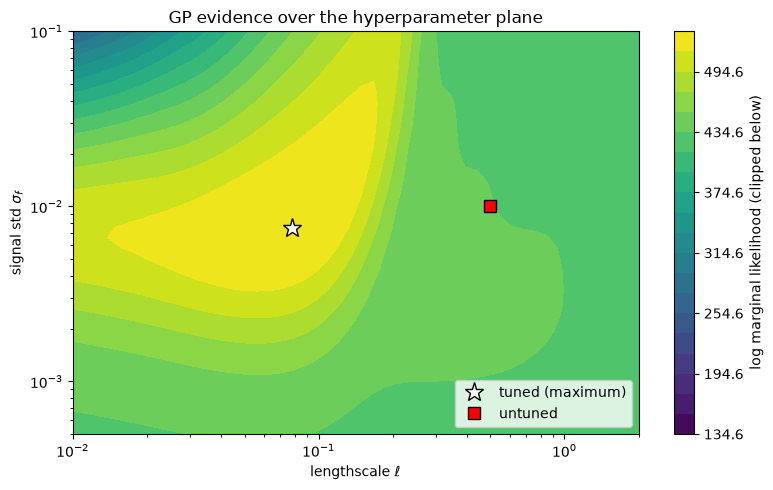

In [5]:
# Evidence of the four models
evidence = [model_blr_right.log_marginal_likelihood(p_train, h_train),
            model_blr_wrong.log_marginal_likelihood(p_train, h_train),
            model_gp.log_marginal_likelihood(p_train, h_train),
            model_gp_untuned.log_marginal_likelihood(p_train, h_train)]
print(f"{'model':<28}{'log evidence':>14}")
print("-" * 42)
for label, lml in zip(labels_11, evidence):
    print(f"{label:<28}{lml:>14.1f}")
print("-" * 42)
print("Higher is better.")

# Map of the GP evidence over the hyperparameter plane
lengthscales = lengthscale_grid
signal_stds = signal_std_grid
lml_grid = np.zeros((len(signal_stds), len(lengthscales)))
probe = Identifier_GP(noise_std=sigma_meas)
for i, sf in enumerate(signal_stds):
    for j, l in enumerate(lengthscales):
        probe.lengthscale, probe.signal_std = l, sf
        lml_grid[i, j] = probe.log_marginal_likelihood(p_train, h_train)

_, ax = plt.subplots(figsize=(8, 5))
levels = np.linspace(lml_opt - 400, lml_opt, 21)
cs = ax.contourf(lengthscales, signal_stds, np.maximum(lml_grid, lml_opt - 400), levels=levels, cmap='viridis')
plt.colorbar(cs, ax=ax, label='log marginal likelihood (clipped below)')
ax.plot(l_opt, sf_opt, 'w*', markersize=14, markeredgecolor='k', label='tuned (maximum)')
ax.plot(model_gp_untuned.lengthscale, model_gp_untuned.signal_std, 'rs', markersize=9,
        markeredgecolor='k', label='untuned')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'lengthscale $\ell$'); ax.set_ylabel(r'signal std $\sigma_f$')
ax.set_title('GP evidence over the hyperparameter plane')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### **Results Analysis**

Read the evidence values from the table and the optimum from the map. The residual term penalizes mismatch that a fixed-hyperparameter posterior covariance cannot see; the log determinant accounts for the prior covariance volume. The selected GP is the maximum **on the specified grid**.

These scores depend on the chosen priors and search ranges. A high training evidence does not certify gap interpolation, derivative calibration, or closed-loop safety. Held-out checks and multiple independent training records would be needed for broader claims. The fixed-frequency BLR and RBF GP remain different structural hypotheses even after matching their scale-tuning protocol.


<br>

----

### **Part 2: Gaussian Process MPC**

#### **The Learned Model and the Quantity the Controller Needs**

We now take the tuned GP of Part 1 into closed loop. To embed it in the optimal control problem the model is converted into CasADi expressions, exactly as the BLR model was in Chapter 6.2.

The controller needs three things from the model, and the third is easy to get wrong. The dynamics

$$
\dot p = v, \qquad \dot v = u\cos\theta(p) - g\sin\theta(p)\cos\theta(p)
$$

depend on the terrain **only through the inclination** $\theta(p) = \arctan\big(h'(p)\big)$. What propagates into the process noise is therefore the uncertainty of the *slope*, $\mathrm{Var}[h'(p)]$, and not the uncertainty of the height, $\mathrm{Var}[h(p)]$. These are different objects, and the first cannot be recovered from the second: it is the second mixed derivative of the posterior covariance,

$$
\mathrm{Var}[h'(p)] = \frac{\partial^2}{\partial p \, \partial p'} \, \mathrm{Cov}\big[h(p), h(p')\big] \Big|_{p' = p},
$$

which for the squared-exponential kernel evaluates to $\sigma_f^2/\ell^2 - (\partial_p k_*)^\top K^{-1} (\partial_p k_*)$. Differentiating the marginal variance with respect to $p$ would give a different, signed quantity. `construct_gp_casadi_expression(..., include_noise=False)` returns all three latent functions: the posterior mean $h(p)$, the height variance $\mathrm{Var}[h(p)]$, and the slope variance $\mathrm{Var}[h'(p)]$.

Part 2 compares tuned and untuned GP controllers, not BLR versus GP controllers. Chapter 6.2 uses a different control experiment, so its trajectories are not a matched baseline for this chapter.


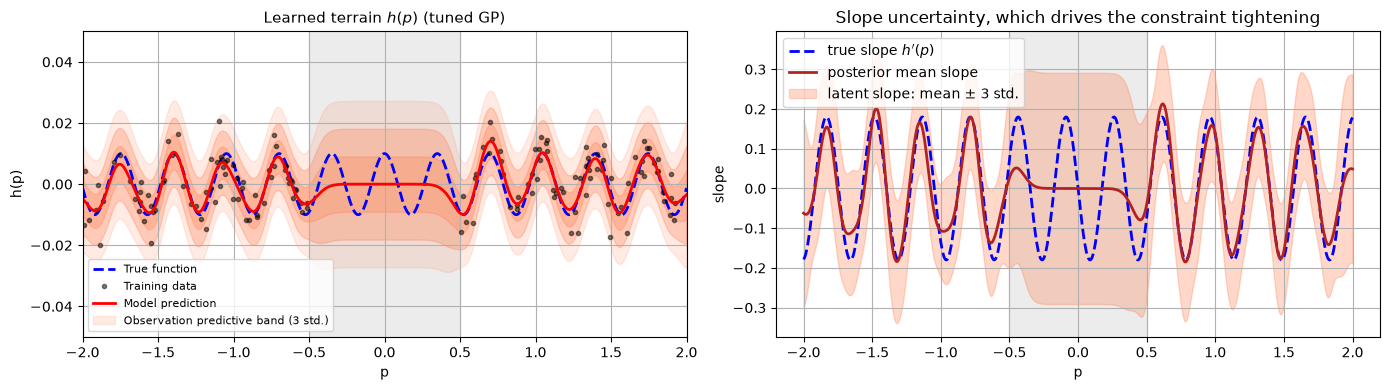

slope std where data is dense: 0.0467
slope std inside the gap     : 0.0970


In [6]:
# Convert the tuned GP to CasADi so the model can be used inside the MPC
h_gp, sigma2_h_gp, sigma2_dh_gp = construct_gp_casadi_expression(model_gp, include_noise=False)

# Inspect the two quantities the controller needs
std_slope = np.array([np.sqrt(float(sigma2_dh_gp(p))) for p in p_test.ravel()])
true_slope = -terrain_param * 18 * np.sin(18 * p_test.ravel())
p_slope = ca.MX.sym("p_slope")
slope_gp = ca.Function("slope_gp", [p_slope], [ca.jacobian(h_gp(p_slope), p_slope)])
mean_slope = np.array([float(slope_gp(p)) for p in p_test.ravel()])

_, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_model(model_gp, p_test, true_func, axes[0], gap=gap, title="Learned terrain $h(p)$ (tuned GP)",
           ylim=(-0.05, 0.05), xlim=(-2, 2))

axes[1].plot(p_test, true_slope, 'b--', linewidth=2, label="true slope $h'(p)$")
axes[1].plot(p_test, mean_slope, color='firebrick', linewidth=2, label="posterior mean slope")
axes[1].fill_between(p_test.ravel(), mean_slope - 3 * std_slope, mean_slope + 3 * std_slope,
                     color='coral', alpha=0.3, label="latent slope: mean ± 3 std.")
axes[1].axvspan(gap[0], gap[1], color='gray', alpha=0.15, zorder=0)
axes[1].set_xlabel("p"); axes[1].set_ylabel("slope"); axes[1].grid(True); axes[1].legend()
axes[1].set_title("Slope uncertainty, which drives the constraint tightening")
plt.tight_layout(); plt.show()

print(f"slope std where data is dense: {np.sqrt(float(sigma2_dh_gp(-1.2))):.4f}")
print(f"slope std inside the gap     : {np.sqrt(float(sigma2_dh_gp(0.0))):.4f}")

#### **Stochastic MPC with a Learned Model**

The implementation uses a first-order covariance approximation around the shifted previous MPC trajectory. With an assumed ancillary gain $K$ it propagates

$$
\Sigma^x_{i+1|k}=(A_i+B_iK)\Sigma^x_{i|k}(A_i+B_iK)^\top+\Sigma^w(\mu_i,u_i),\qquad \Sigma^x_{0|k}=0.
$$

Both gravity and propulsion depend on the same uncertain slope $z=h'(p)$. For acceleration $a(z,u)=u/\sqrt{1+z^2}-gz/(1+z^2)$ the variance approximation is $(\partial a/\partial z)^2\operatorname{Var}[z]$, including the covariance between those two terms. The discrete injection uses $\Delta t^2$ times this acceleration variance in the velocity coordinate (an Euler approximation).

State bounds are tightened by $\beta\sqrt{\operatorname{diag}\Sigma^x}$. For a scalar Gaussian, $\beta=2$ corresponds to 95.45% central coverage (97.72% for a single upper bound). This is **not** a joint state or horizon guarantee. The code ignores temporal correlations of the static learned terrain error and state-model correlations. The ancillary gain is used only for covariance prediction; it is not an explicitly applied tube feedback law or the verified sensitivity of the MPC policy.

Constraints are softened and the requested margins are not capped: if $\beta\sqrt{\operatorname{diag}\Sigma^x}$ exceeds the half-width of the box, the tightened bounds cross, the stage box is empty and the soft constraints decide. Such empty stage boxes are counted once each, even if both coordinates are affected. Those choices further prevent interpreting $\beta$ as an achieved chance-constraint level. Solver failures are raised explicitly. The experiment measures sampled constraint violations on this one deterministic terrain; it does not establish a safety guarantee.


In [7]:
# The controller is implemented in ex6_SysID/gpmpc_utils.py and shared with Chapter 6.4.
from ex6_SysID.gpmpc_utils import GPMPCController

<br>

----

#### **Example 2.1: Certainty-Equivalent Control vs. Constraint Tightening**

We run the same controller at $\beta \in \{0, 1, 2, 3\}$ against the real plant, and include as a reference the same controller given the true terrain and zero model uncertainty. It is a reference under the same finite-horizon objective and soft constraints, not a global performance ceiling. Both positive and negative sampled speed violations are counted. The reported cost is a common unscaled trajectory score (including the final state), not the solver objective including slack penalties.

In [8]:
def make_learned_env(h_func, sigma2_h_func, sigma2_dh_func):
    '''Build an Env/Dynamics pair that the controller believes in.'''
    env_l = Env(case_real, x0, xT, symbolic_h_mean_ext=h_func, symbolic_h_cov_ext=sigma2_h_func,
                symbolic_dh_cov_ext=sigma2_dh_func, param=terrain_param, state_lbs=state_lbs,
                state_ubs=state_ubs, input_lbs=input_lbs, input_ubs=input_ubs)
    return env_l, Dynamics(env_l)


def closed_loop_cost(states, inputs):
    err = np.asarray(states) - xT
    return float(np.sum(np.einsum('ij,jk,ik->i', err, Q, err)) + R[0, 0] * np.sum(np.asarray(inputs)**2))


def run_closed_loop(env_l, dynamics_l, beta, name):
    '''Simulate the controller, which trusts env_l, against the real plant.'''
    controller = GPMPCController(env_l, dynamics_l, Q, R, Qf, N, freq, beta=beta, name=name, verbose=False)
    sim = Simulator(dynamics_real, controller, env_real, 1/freq, t_terminal)
    sim.run_simulation()
    states, inputs = np.array(sim.state_traj), np.array(sim.input_traj)
    v = states[:, 1]
    return dict(states=states, inputs=inputs, sigma=np.array(controller.Sigma_x_log),
                peak_v=np.abs(v).max(), violation=max(0.0, np.abs(v).max() - v_max),
                steps_over=int((np.abs(v) > v_max + 1e-6).sum()),
                cost=closed_loop_cost(states, inputs), n_empty=controller.n_empty,
                final_error=abs(states[-1, 0] - target_position))


def report(rows):
    print(f"{'controller':<32}{'peak |v|':>9}{'violation':>11}{'steps>lim':>11}{'cost':>9}{'final err':>11}{'empty':>7}")
    print("-" * 90)
    for label, r in rows:
        print(f"{label:<32}{r['peak_v']:>9.4f}{r['violation']:>11.4f}{r['steps_over']:>11d}"
              f"{r['cost']:>9.1f}{r['final_error']:>11.4f}{r['n_empty']:>7d}")
    print("-" * 90)
    print(f"speed limit v_max = {v_max}")

In [9]:
# True-model reference: the same controller, but given the true terrain and no model uncertainty
p_sym_zero = ca.MX.sym("p")
zero_var = ca.Function("zero_var", [p_sym_zero], [ca.MX(0.0)])
env_true = Env(case_real, x0, xT, symbolic_h_cov_ext=zero_var, symbolic_dh_cov_ext=zero_var,
               param=terrain_param, state_lbs=state_lbs, state_ubs=state_ubs,
               input_lbs=input_lbs, input_ubs=input_ubs)
res_true = run_closed_loop(env_true, Dynamics(env_true), 0.0, "MPC_true_model")

# GP-MPC at increasing confidence levels
betas = [0.0, 1.0, 2.0, 3.0]
res_gp = {}
for b in betas:
    env_l, dyn_l = make_learned_env(h_gp, sigma2_h_gp, sigma2_dh_gp)
    res_gp[b] = run_closed_loop(env_l, dyn_l, b, f"GPMPC_beta{int(b)}")

report([("MPC, true model (reference)", res_true)] +
       [(f"GP-MPC, beta = {b:.0f}" + ("  (certainty equiv.)" if b == 0 else ""), res_gp[b]) for b in betas])

field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
Simulation finished, will start plotting
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
Simulation finished, will start plotting
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
Simulation finished, will start plotting
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
Simulation finished, will start plotting
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOpti

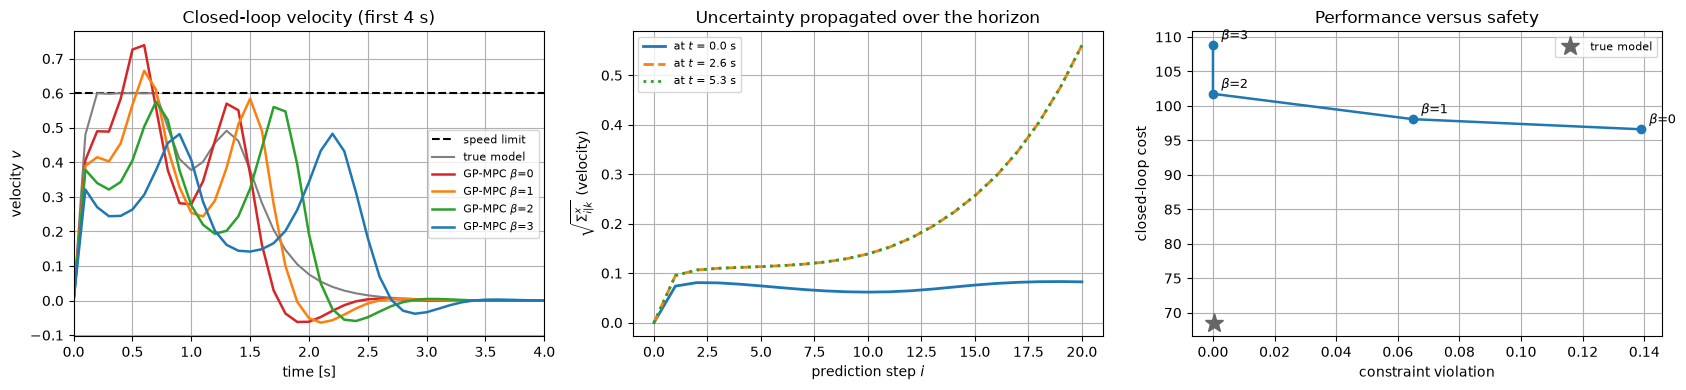

In [10]:
t = np.arange(len(res_true['states'])) / freq
beta_colors = ['tab:red', 'tab:orange', 'tab:green', 'tab:blue']

_, axes = plt.subplots(1, 3, figsize=(17, 4))

# Closed-loop velocity against the speed limit
axes[0].axhline(v_max, color='k', linestyle='--', linewidth=1.5, label='speed limit')
axes[0].plot(t, res_true['states'][:, 1], color='0.5', linewidth=1.5, label='true model')
for b, c in zip(betas, beta_colors):
    axes[0].plot(t, res_gp[b]['states'][:, 1], color=c, linewidth=1.8, label=rf'GP-MPC $\beta$={b:.0f}')
axes[0].set_xlim(0, 4)
axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('velocity $v$'); axes[0].grid(True)
axes[0].legend(fontsize=8); axes[0].set_title('Closed-loop velocity (first 4 s)')

# Uncertainty growth along the prediction horizon
sig = res_gp[2.0]['sigma']
for k, style in ((0, '-'), (len(sig)//3, '--'), (2*len(sig)//3, ':')):
    axes[1].plot(np.arange(N + 1), np.sqrt(sig[k][:, 1]), style, linewidth=2,
                 label=f'at $t$ = {k/freq:.1f} s')
axes[1].set_xlabel('prediction step $i$'); axes[1].set_ylabel(r'$\sqrt{\Sigma^x_{i|k}}$ (velocity)')
axes[1].grid(True); axes[1].legend(fontsize=8)
axes[1].set_title('Uncertainty propagated over the horizon')

# Performance / safety trade-off
axes[2].plot([res_gp[b]['violation'] for b in betas], [res_gp[b]['cost'] for b in betas],
             'o-', color='tab:blue', linewidth=1.8)
for b in betas:
    axes[2].annotate(rf'$\beta$={b:.0f}', (res_gp[b]['violation'], res_gp[b]['cost']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[2].plot(res_true['violation'], res_true['cost'], '*', color='0.4', markersize=14, label='true model')
axes[2].set_xlabel('constraint violation'); axes[2].set_ylabel('closed-loop cost')
axes[2].grid(True); axes[2].legend(fontsize=8)
axes[2].set_title('Performance versus safety')

plt.tight_layout(); plt.show()

#### **Results Analysis**

Use the current report and plots to compare sampled speed violation, tracking cost, final position error, and empty stage boxes as $\beta$ changes. Certainty-equivalent control ignores uncertainty; positive $\beta$ requests more margin. Neither monotonic improvement nor constraint satisfaction is guaranteed for this nonlinear controller.

The true-model reference also has finite-horizon, input-effort, terminal-cost and soft-constraint tradeoffs. A nonzero final error cannot be attributed solely to the GP or to missing data. The covariance curves are the controller's approximation, not measured state-error distributions. An empty stage box or soft-constraint violation invalidates a literal confidence-level interpretation.


<br>

----

#### **Example 2.2: When the Uncertainty Estimate Is Miscalibrated**

Example 2.1 used the GP whose hyperparameters were tuned in Part 1. In practice they are often fixed offline, because re-optimizing them online is expensive. We now repeat the experiment with the **untuned GP of Example 1.1**: the same data and the same kernel, but $\ell = 0.5$ and $\sigma_f = 0.01$, chosen without inspecting the data.

The mean of this model is visibly worse, but that is not the point. The point is what it reports about its own reliability, and what the constraint tightening then does with that report.

In [11]:
# The untuned GP of Example 1.1, converted to CasADi
h_un, var_un, dvar_un = construct_gp_casadi_expression(model_gp_untuned, include_noise=False)

print(f"slope std inside the gap:  tuned {np.sqrt(float(sigma2_dh_gp(0.0))):.4f}   "
      f"untuned {np.sqrt(float(dvar_un(0.0))):.4f}   "
      f"(the untuned model claims {np.sqrt(float(sigma2_dh_gp(0.0)))/np.sqrt(float(dvar_un(0.0))):.0f}x less uncertainty)\n")

res_un = {}
for b in (2.0, 3.0):
    env_u, dyn_u = make_learned_env(h_un, var_un, dvar_un)
    res_un[b] = run_closed_loop(env_u, dyn_u, b, f"GPMPCun_beta{int(b)}")

report([(f"GP-MPC tuned,   beta = {b:.0f}", res_gp[b]) for b in (2.0, 3.0)] +
       [(f"GP-MPC UNTUNED, beta = {b:.0f}", res_un[b]) for b in (2.0, 3.0)])

slope std inside the gap:  tuned 0.0970   untuned 0.0076   (the untuned model claims 13x less uncertainty)

field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
Simulation finished, will start plotting
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
Simulation finished, will start plotting
controller                       peak |v|  violation  steps>lim     cost  final err  empty
------------------------------------------------------------------------------------------
GP-MPC tuned,   beta = 2           0.5754     0.0000          0    101.7     0.2807    265
GP-MPC tuned,   beta = 3           0.4827     0.0000          0    108.8     0.2785    481
GP-MPC UNTUNED, beta = 2           0.7022     0.1022          2    100.2  

#### **Results Analysis**

The printed slope standard deviations compare two model estimates at the center of the gap. Their ratio is **not** the ratio of true uncertainty, and it is not the ratio of MPC margins: the two models also change the mean dynamics, linearization points, ancillary gain and optimized trajectories.

Compare the tuned and untuned runs at the same $\beta$ using the table. This experiment changes both mean and covariance, so it cannot isolate the causal effect of calibration alone. Raising $\beta$ may reduce violations for this trajectory, but it does not validate a misspecified variance. Height-observation coverage and evidence are useful diagnostics; derivative checks and repeated closed-loop trials are needed for stronger conclusions.


<blockquote style="
    padding: 18px 20px;
    margin: 1.2em 0;
    background: rgba(56, 139, 253, 0.12);      
    border-left: 4px solid rgba(56, 139, 253, 0.85);
    border-radius: 6px;
    color: inherit !important;                  
">

##### **Takeaway:**

- The same data can support very different predictions under different structural priors. A correct periodic basis supplies information that an RBF GP does not have; BLR and GP inference coincide when their priors coincide.
- Shared noise, signal-scale tuning and evaluation samples make the comparison explicit. Hyperparameter selection and finite-grid evidence do not certify model or derivative calibration.
- New-observation height bands include measurement noise. MPC needs latent slope variance, propagated through the derivative of the complete acceleration model.
- The controller uses approximate covariance propagation and soft constraints. Its plots show empirical tradeoffs on this run, not guaranteed safety or general method rankings.

</blockquote>

<br>

----

### **Appendix: Figures for the Tutorial Paper**

The first cell below redraws Example 1.1 at single-column width and saves it to `figures/`; it contains no new model fitting. The second cell builds the GP-MPC figure of the paper with `ex6_SysID/tutorial_gp_mpc_figure.py`. That script re-runs the closed loop of Example 2.1 with the weights used in the paper, $Q = \mathrm{diag}(5, 0)$ and $R = 0.01$ instead of the chapter's $Q = \mathrm{diag}(5, 5)$ and $R = 0.1$, so that no velocity penalty slows the plan down and the car reaches the target. It shows the problem setup, the open-loop plan at $t = 0$ in the state space with its $2\sigma$ ellipses and the tightened speed limit, and the performance-versus-safety trade-off over $\beta$. The gray overlay is the same plan under open-loop covariance propagation, i.e. without the ancillary gain. Closed-loop results are cached in `figures/gp_mpc_redesign_data/`, and the other parameter settings studied are available as named cases in the script (`python ex6_SysID/tutorial_gp_mpc_figure.py --all`). The height bands include observation noise; the MPC covariance is based on latent slope uncertainty.

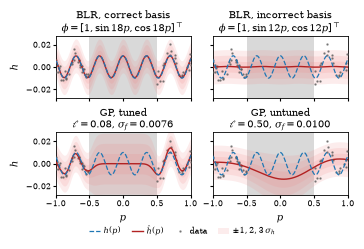

In [12]:
PAPER_RC = {"font.size": 7, "axes.titlesize": 7, "axes.labelsize": 7,
            "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
            "axes.linewidth": 0.6, "lines.linewidth": 1.0,
            "font.family": "serif", "mathtext.fontset": "dejavuserif", "pdf.fonttype": 42}

with plt.rc_context(PAPER_RC):
    fig, axes = plt.subplots(2, 2, figsize=(3.5, 2.3), sharex=True, sharey=True)
    p_flat = p_test.ravel()
    h_true = np.array([float(true_func(p)) for p in p_flat])
    for ax, model, title in zip(axes.ravel(), models_11, titles_11):
        mean, std = predictive(model, p_test)
        ax.axvspan(*gap, color="0.85", zorder=0, linewidth=0)
        for j in (3, 2, 1):
            ax.fill_between(p_flat, mean - j*std, mean + j*std, color="lightcoral", alpha=0.15,
                            linewidth=0, zorder=2, label=r"$\pm 1,2,3\,\sigma_h$" if j == 3 else None)
        ax.plot(p_train, h_train, ".", color="0.35", markersize=1.4, alpha=0.7, zorder=3, label="data")
        ax.plot(p_flat, mean, "-", color="firebrick", zorder=4, label=r"$\hat h(p)$")
        ax.plot(p_flat, h_true, "--", color="tab:blue", linewidth=0.9, zorder=5, label=r"$h(p)$")
        ax.set_title(title, pad=3)
        ax.set_ylim(-0.028, 0.028); ax.set_xlim(-1.0, 1.0)
        ax.set_yticks([-0.02, 0, 0.02]); ax.set_xticks([-1, -0.5, 0, 0.5, 1])
        ax.tick_params(length=2, pad=1.5)
    for ax in axes[1]:
        ax.set_xlabel("$p$")
    for ax in axes[:, 0]:
        ax.set_ylabel("$h$")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    order = [labels.index(l) for l in (r"$h(p)$", r"$\hat h(p)$", "data", r"$\pm 1,2,3\,\sigma_h$")]
    fig.legend([handles[i] for i in order], [labels[i] for i in order], loc="lower center", ncol=4,
               frameon=False, handlelength=1.4, columnspacing=1.2, handletextpad=0.4, bbox_to_anchor=(0.5, -0.03))
    fig.tight_layout(pad=0.3, h_pad=0.6, w_pad=0.6, rect=[0, 0.04, 1, 1])
    fig.savefig(os.path.join(FIG_DIR, "tutorial_model_learning.pdf"))
    fig.savefig(os.path.join(FIG_DIR, "tutorial_model_learning.png"), dpi=300)
    plt.show()

[Q50R001_overlay] wrote /Users/siqizhou/Documents/Github Repos/core_course_examples-1/ex6_SysID/figures/tutorial_gp_mpc_redesign_Q50R001_overlay.png/.pdf


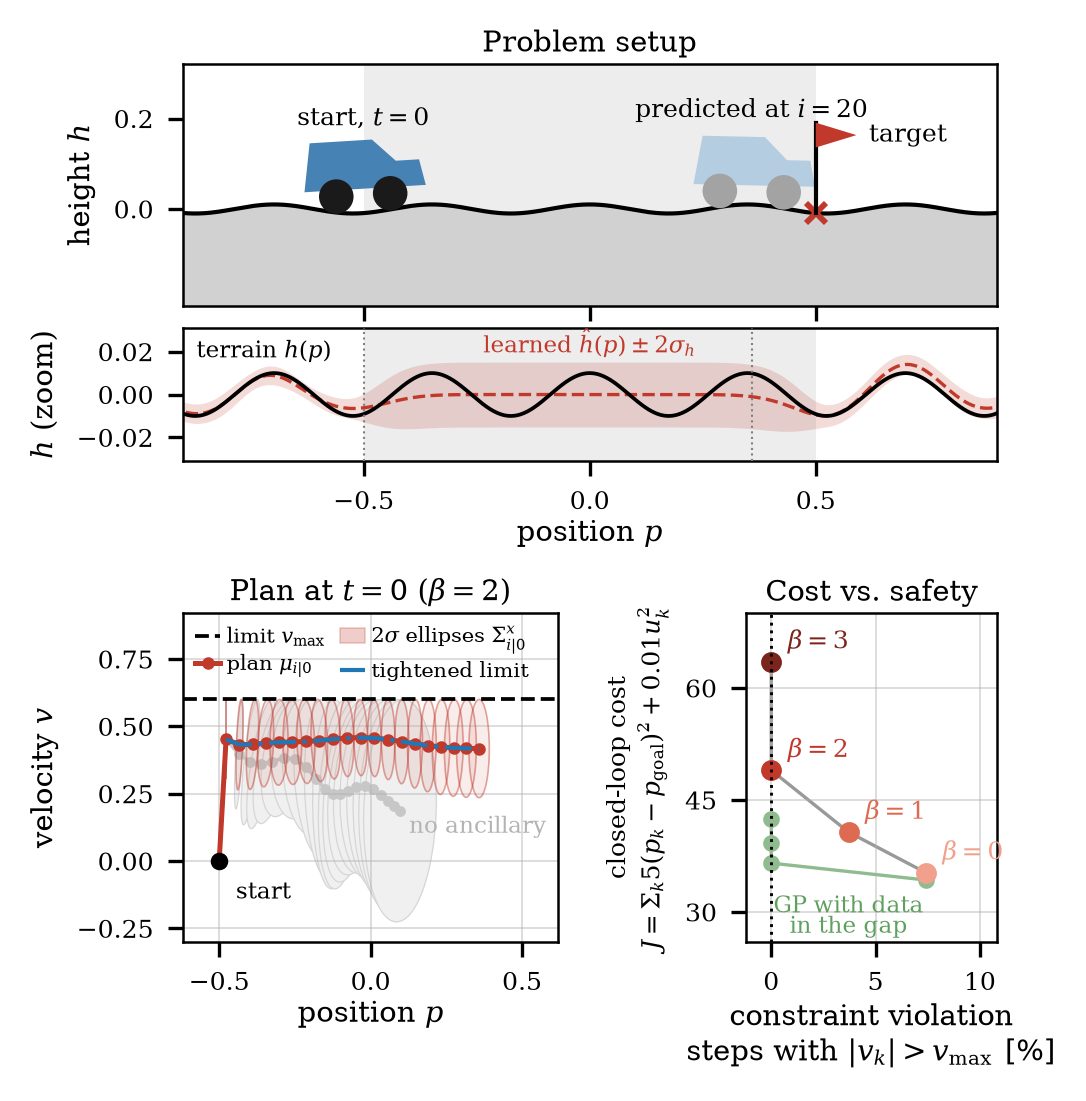

In [13]:
# GP-MPC figure of the paper, built by ex6_SysID/tutorial_gp_mpc_figure.py. The script re-runs the
# closed loop with the paper's weights, Q = diag(5, 0) and R = 0.01, caches the results in
# figures/gp_mpc_redesign_data/, and overlays the same plan with open-loop covariance propagation
# (no ancillary gain) in gray. Pass rerun=True to recompute instead of using the cache.
import shutil
from IPython.display import Image, display
from ex6_SysID.tutorial_gp_mpc_figure import make_figure, CASES, FIG_DIR as PAPER_FIG_DIR

make_figure("Q50R001_overlay")
for ext in ("png", "pdf"):   # the paper includes the figure under this name
    shutil.copy(os.path.join(PAPER_FIG_DIR, f"{CASES['Q50R001_overlay']['output']}.{ext}"),
                os.path.join(FIG_DIR, f"tutorial_gp_mpc.{ext}"))
display(Image(os.path.join(FIG_DIR, "tutorial_gp_mpc.png"), width=520))